In [ ]:
import os
from scipy.io import loadmat

DATA_DIR = "./sim_test/output_folder"

SIM_START = 1
SIM_END = 300
STEP_START = 1
STEP_END = 200

# choose what mat fields must exist
REQUIRED_MAT_KEYS = ["K", "P", "phi", "VX", "VY"]
# examples:
# REQUIRED_MAT_KEYS = ["K", "P", "phi"]
# REQUIRED_MAT_KEYS = ["K", "P", "phi", "K_255", "P_255", "phi_255"]
REQUIRED_MAT_KEYS = ["K", "P", "phi", "K_u8", "P_u8", "phi_u8", "K_255", "P_255", "phi_255"]

complete_sims = []
incomplete_sims = {}

for sim in range(SIM_START, SIM_END + 1):
    bad_steps = []

    for step in range(STEP_START, STEP_END + 1):
        issues = []

        phi_jpg = os.path.join(DATA_DIR, f"Image-{sim}-{step}_phi.jpg")
        p_jpg   = os.path.join(DATA_DIR, f"Image-{sim}-{step}_P.jpg")
        k_jpg   = os.path.join(DATA_DIR, f"Image-{sim}-{step}_K.jpg")
        mat_path = os.path.join(DATA_DIR, f"State-{sim}-{step}.mat")

        # check jpgs
        if not os.path.exists(phi_jpg):
            issues.append("missing phi jpg")
        if not os.path.exists(p_jpg):
            issues.append("missing P jpg")
        if not os.path.exists(k_jpg):
            issues.append("missing K jpg")

        # check mat file + required keys
        if not os.path.exists(mat_path):
            issues.append("missing mat")
        else:
            try:
                data = loadmat(mat_path)
                for key in REQUIRED_MAT_KEYS:
                    if key not in data:
                        issues.append(f"missing mat key: {key}")
            except Exception as e:
                issues.append(f"mat read error: {e}")

        if issues:
            bad_steps.append((step, issues))

    if bad_steps:
        incomplete_sims[sim] = bad_steps
    else:
        complete_sims.append(sim)

print("Complete sims:")
print(complete_sims)

print("\nIncomplete sims:")
for sim, bad_steps in incomplete_sims.items():
    print(f"\nSim {sim}:")
    for step, issues in bad_steps:
        print(f"  Step {step}: {', '.join(issues)}")

Complete sims:
[26, 27, 28]

Incomplete sims:
Sim 1: missing/incomplete steps [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200]
Sim 2: missing/incomplete ste


=== jpg_raw255 vs jpg_neg11 ===
jpg_raw255   | epochs=10 | final_val=157.053 | best_val=146.968 @ epoch 6 | mean_val=169.9 | auc_val=1495.66
jpg_neg11    | epochs=10 | final_val=0.0112415 | best_val=0.0112415 @ epoch 10 | mean_val=0.0141026 | auc_val=0.126635
Best val improvement (jpg_neg11 vs jpg_raw255): 99.99%
Final val improvement (jpg_neg11 vs jpg_raw255): 99.99%


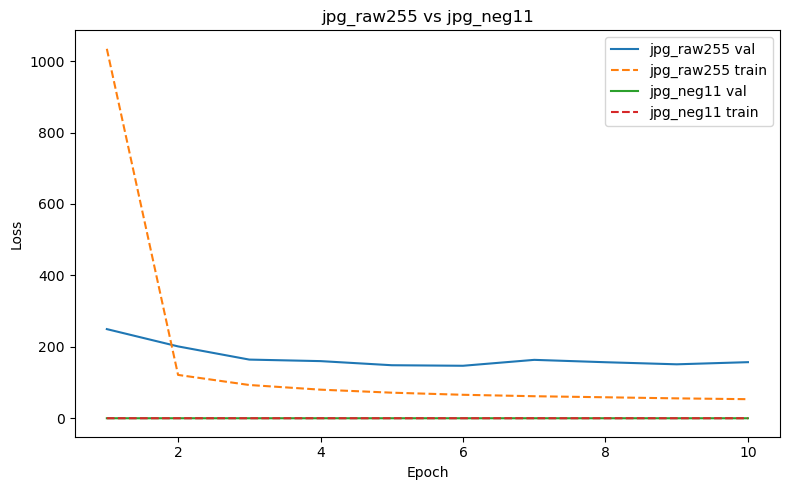

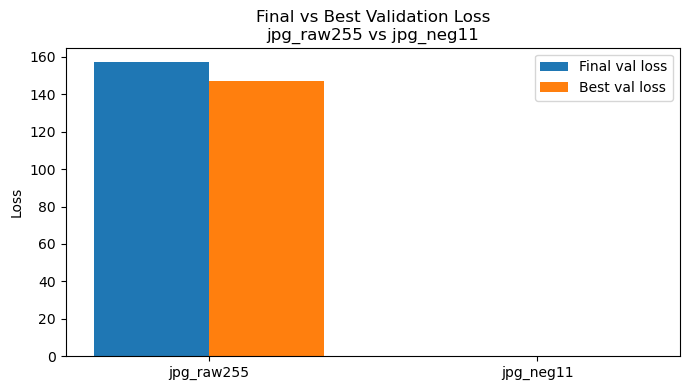


=== jpg_raw255 vs mat_255 ===
jpg_raw255   | epochs=10 | final_val=157.053 | best_val=146.968 @ epoch 6 | mean_val=169.9 | auc_val=1495.66
mat_255      | epochs=10 | final_val=150.582 | best_val=150.582 @ epoch 10 | mean_val=174.993 | auc_val=1534.67
Best val improvement (mat_255 vs jpg_raw255): -2.46%
Final val improvement (mat_255 vs jpg_raw255): 4.12%


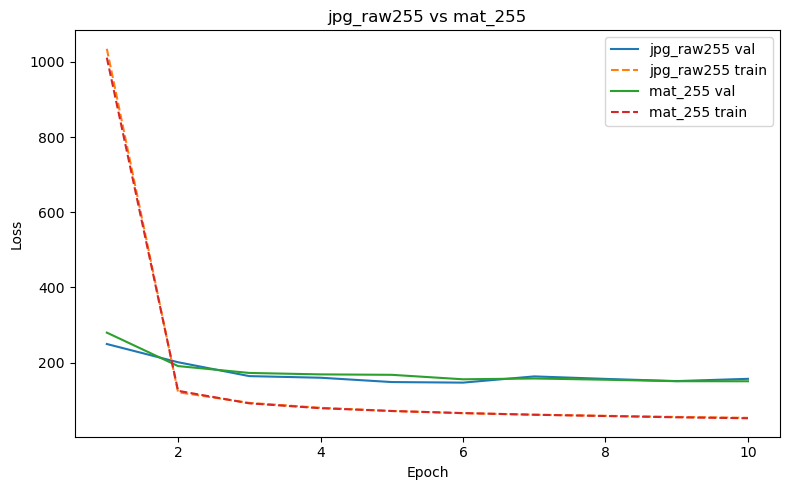

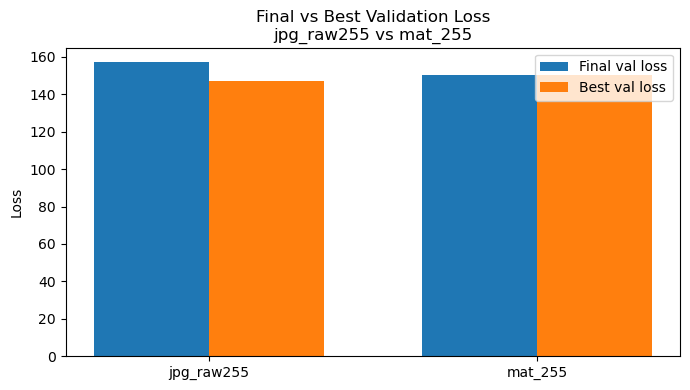

In [13]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt

RESULTS_DIR = "./experiment_results"

# adjust names here to match your actual saved files
PAIR_1 = ("jpg_01", "jpg_neg11")      # normalization comparison
PAIR_1 = ("jpg_raw255", "jpg_neg11")      # normalization comparison
PAIR_2 = ("jpg_raw255", "mat_255")    # representation comparison
#PAIR_2 = ("jpg_raw255", "jpg_neg11")    # representation comparison
#PAIR_2 = ("jpg_01", "mat_raw")    # representation comparison
# If your names are different, e.g. "matraw" / "mat255", change them here.
# For example:
# PAIR_2 = ("jpg_01", "mat_raw")

def load_metrics(run_name):
    path = os.path.join(RESULTS_DIR, f"{run_name}_metrics.json")
    with open(path, "r") as f:
        return json.load(f)

def summarize_run(run_name, metrics):
    train = np.array(metrics["train_losses"], dtype=float)
    val = np.array(metrics["val_losses"], dtype=float)

    summary = {
        "name": run_name,
        "n_epochs": len(val),
        "final_train": float(train[-1]),
        "final_val": float(val[-1]),
        "best_val": float(val.min()),
        "best_epoch": int(val.argmin() + 1),
        "mean_val": float(val.mean()),
        "auc_val": float(np.trapezoid(val, dx=1.0)),
    }
    return summary

def print_pair_summary(name1, name2):
    m1 = load_metrics(name1)
    m2 = load_metrics(name2)

    s1 = summarize_run(name1, m1)
    s2 = summarize_run(name2, m2)

    print(f"\n=== {name1} vs {name2} ===")
    for s in [s1, s2]:
        print(
            f"{s['name']:12s} | "
            f"epochs={s['n_epochs']:2d} | "
            f"final_val={s['final_val']:.6g} | "
            f"best_val={s['best_val']:.6g} @ epoch {s['best_epoch']} | "
            f"mean_val={s['mean_val']:.6g} | "
            f"auc_val={s['auc_val']:.6g}"
        )

    # percent improvement of run2 over run1 in best val
    if s1["best_val"] != 0:
        best_improve = 100.0 * (s1["best_val"] - s2["best_val"]) / abs(s1["best_val"])
        print(f"Best val improvement ({name2} vs {name1}): {best_improve:.2f}%")

    if s1["final_val"] != 0:
        final_improve = 100.0 * (s1["final_val"] - s2["final_val"]) / abs(s1["final_val"])
        print(f"Final val improvement ({name2} vs {name1}): {final_improve:.2f}%")

def plot_pair(name1, name2):
    m1 = load_metrics(name1)
    m2 = load_metrics(name2)

    train1 = np.array(m1["train_losses"], dtype=float)
    val1 = np.array(m1["val_losses"], dtype=float)
    train2 = np.array(m2["train_losses"], dtype=float)
    val2 = np.array(m2["val_losses"], dtype=float)

    epochs1 = np.arange(1, len(val1) + 1)
    epochs2 = np.arange(1, len(val2) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs1, val1, label=f"{name1} val")
    plt.plot(epochs1, train1, linestyle="--", label=f"{name1} train")
    plt.plot(epochs2, val2, label=f"{name2} val")
    plt.plot(epochs2, train2, linestyle="--", label=f"{name2} train")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{name1} vs {name2}")
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_bar_compare(name1, name2):
    m1 = load_metrics(name1)
    m2 = load_metrics(name2)

    s1 = summarize_run(name1, m1)
    s2 = summarize_run(name2, m2)

    labels = [name1, name2]
    final_vals = [s1["final_val"], s2["final_val"]]
    best_vals = [s1["best_val"], s2["best_val"]]

    x = np.arange(len(labels))
    width = 0.35

    plt.figure(figsize=(7, 4))
    plt.bar(x - width/2, final_vals, width, label="Final val loss")
    plt.bar(x + width/2, best_vals, width, label="Best val loss")
    plt.xticks(x, labels)
    plt.ylabel("Loss")
    plt.title(f"Final vs Best Validation Loss\n{name1} vs {name2}")
    plt.legend()
    plt.tight_layout()
    plt.show()

def main():
    for a, b in [PAIR_1, PAIR_2]:
        print_pair_summary(a, b)
        plot_pair(a, b)
        plot_bar_compare(a, b)

if __name__ == "__main__":
    main()

In [3]:
import numpy as np

results = {
    "jpg_01": {
        "train": [0.0039412714324850405,0.001616514794919537,0.0013243818308936834,0.001165587130177622,0.0010608621009172696,0.0009693322617249327,0.0008986633674187576,0.0008367064725080227,0.0007796557474423467,0.0007312806981013707],
        "val":   [0.0030772586421032124,0.0026314365926373286,0.002816431497291584,0.0026020964568306227,0.002601418638175043,0.0026108768022580385,0.002675925569734924,0.0027841054517193696,0.0026729366830841174,0.002723167414321021],
    },
    "jpg_neg11": {
        "train": [0.014746680936894447,0.006391553003495322,0.005066189008111453,0.0045624019153086845,0.004174031963216872,0.003900129454704362,0.0036129316157090235,0.0033671372251595417,0.003159875519244381,0.0029997129791328753],
        "val":   [0.01754061011597514,0.016735765720562387,0.017864231800970933,0.015325473558429318,0.013554287361136327,0.013220991294559403,0.012699428997584618,0.01129227400039478,0.011551591293731083,0.011241497411004579],
    },
    "jpg_raw255": {
        "train": [1034.535005145837,121.3583892206856,93.10148630384582,80.05013842082155,71.61037435879365,65.71089468307916,61.66825714322085,58.742063009356926,55.68988299501535,53.382825724986375],
        "val":   [249.6277169863383,201.1879448699951,164.26297062238058,159.9835984357198,148.4731675942739,146.967912607193,163.51405586560568,156.8915539042155,151.0381859143575,157.0533745352427],
    },
    "mat_255": {
        "train": [1010.9542650625324,125.1607907003329,91.8874880441908,78.91164007618941,71.49919581207782,65.99614269277667,61.56427489264894,58.12016550770122,54.738928770623815,52.239328707700274],
        "val":   [279.9256529490153,190.95129585901896,172.7156444644928,168.86013364156088,167.71198031107585,155.832774254481,157.95980688412985,154.67159017880758,150.71455531756084,150.5824240875244],
    },
    "mat_raw": {
        "train": [0.004438869634820714,0.0017112605839978018,0.0013735950122669709,0.0011964841599920919,0.0010865055799461098,0.0010043010665026612,0.0009357061672335727,0.0008768485463803213,0.0008280025056089938,0.0007941525854756901],
        "val":   [0.005205680608924013,0.0038437950973942256,0.0037917992524065386,0.0032094623272132593,0.004010835885371004,0.0038821087479785393,0.003721717356384033,0.002971864370289647,0.0029114333426211183,0.003907974057365209],
    },
}

for name, d in results.items():
    train = np.array(d["train"])
    val = np.array(d["val"])
    best_idx = val.argmin()
    best_val = val[best_idx]
    final_val = val[-1]
    improve_best = 100 * (val[0] - best_val) / abs(val[0])
    improve_final = 100 * (val[0] - final_val) / abs(val[0])
    gap = final_val - train[-1]
    print(
        f"{name:10s} | "
        f"best={best_val:.6g} (epoch {best_idx+1}) | "
        f"final={final_val:.6g} | "
        f"improve_to_best={improve_best:6.2f}% | "
        f"improve_to_final={improve_final:6.2f}% | "
        f"gap={gap:.6g}"
    )

jpg_01     | best=0.00260142 (epoch 5) | final=0.00272317 | improve_to_best= 15.46% | improve_to_final= 11.51% | gap=0.00199189
jpg_neg11  | best=0.0112415 (epoch 10) | final=0.0112415 | improve_to_best= 35.91% | improve_to_final= 35.91% | gap=0.00824178
jpg_raw255 | best=146.968 (epoch 6) | final=157.053 | improve_to_best= 41.13% | improve_to_final= 37.08% | gap=103.671
mat_255    | best=150.582 (epoch 10) | final=150.582 | improve_to_best= 46.21% | improve_to_final= 46.21% | gap=98.3431
mat_raw    | best=0.00291143 (epoch 9) | final=0.00390797 | improve_to_best= 44.07% | improve_to_final= 24.93% | gap=0.00311382


Showing predictions for jpg_01


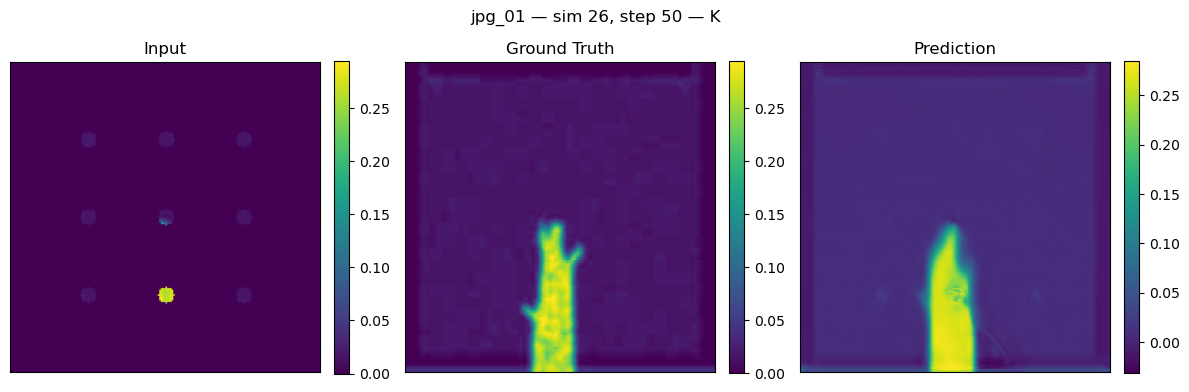

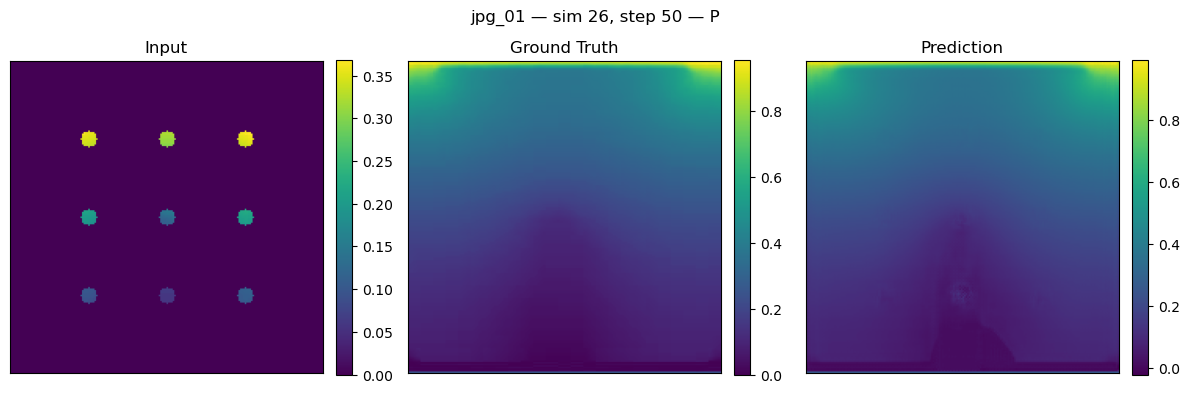

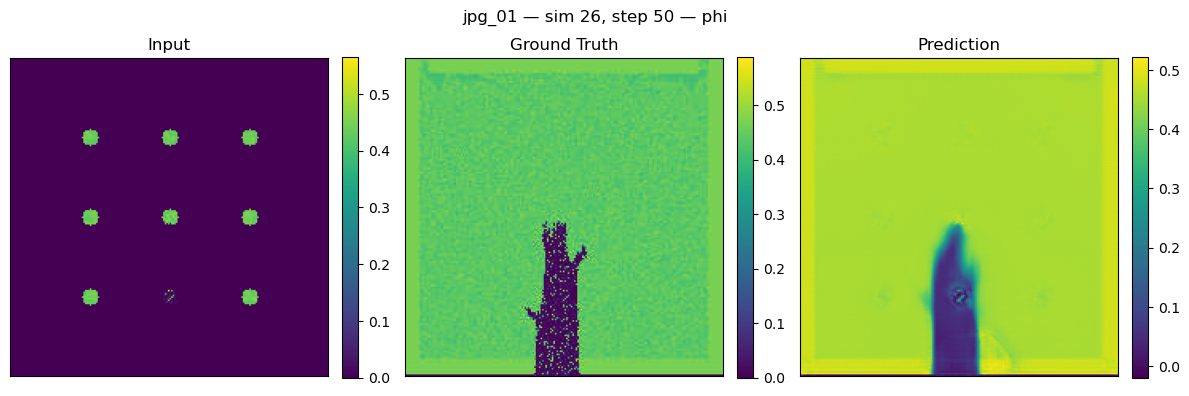

Showing predictions for jpg_neg11


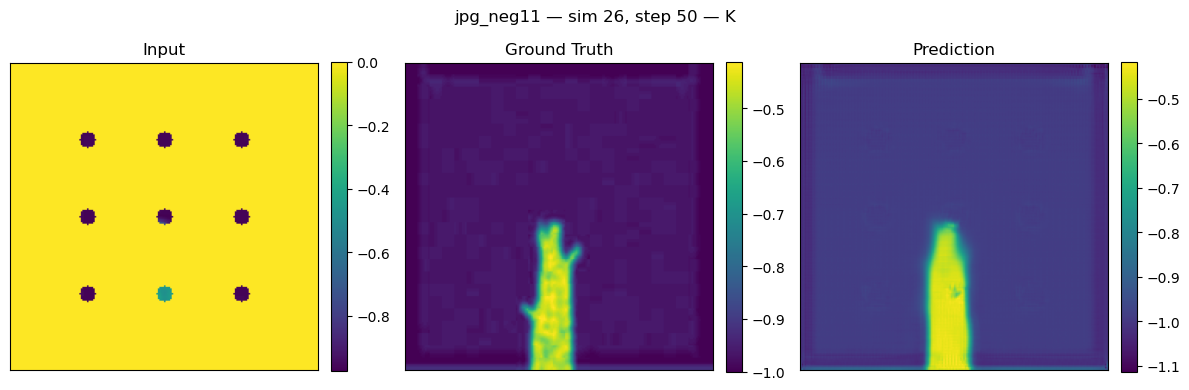

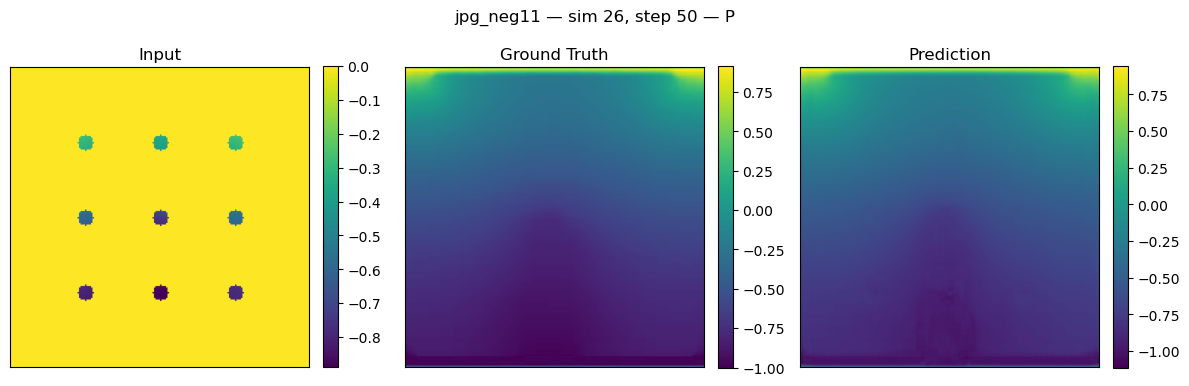

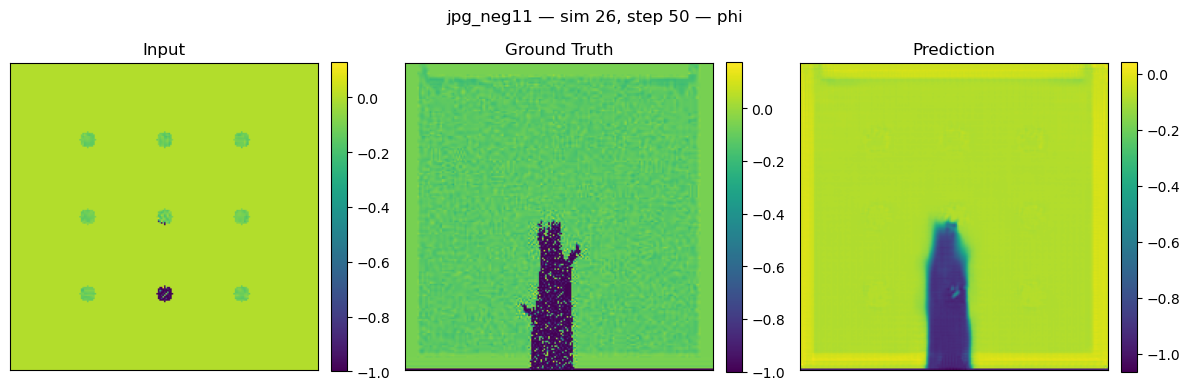

Showing predictions for jpg_raw255


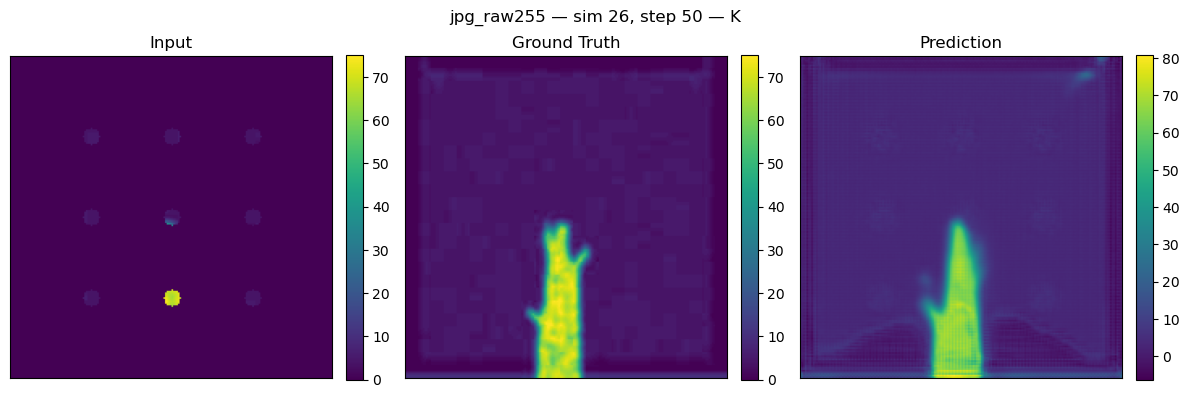

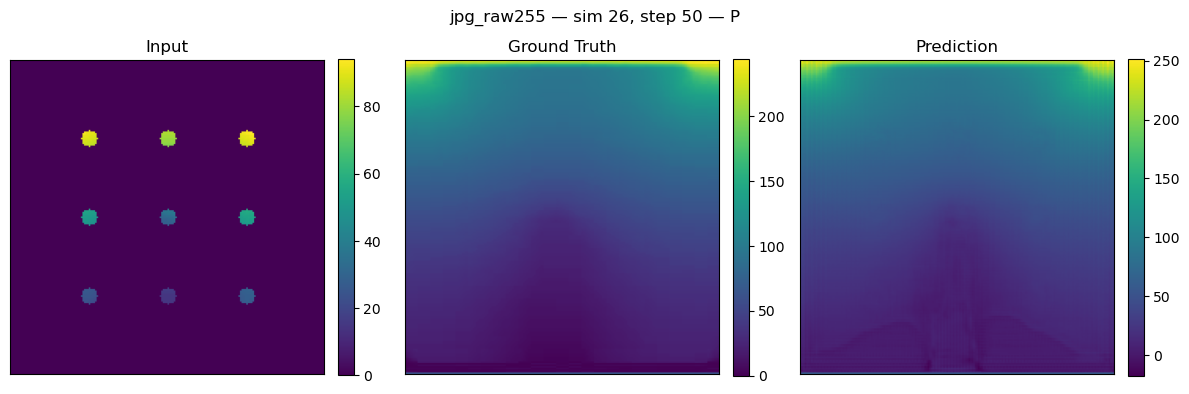

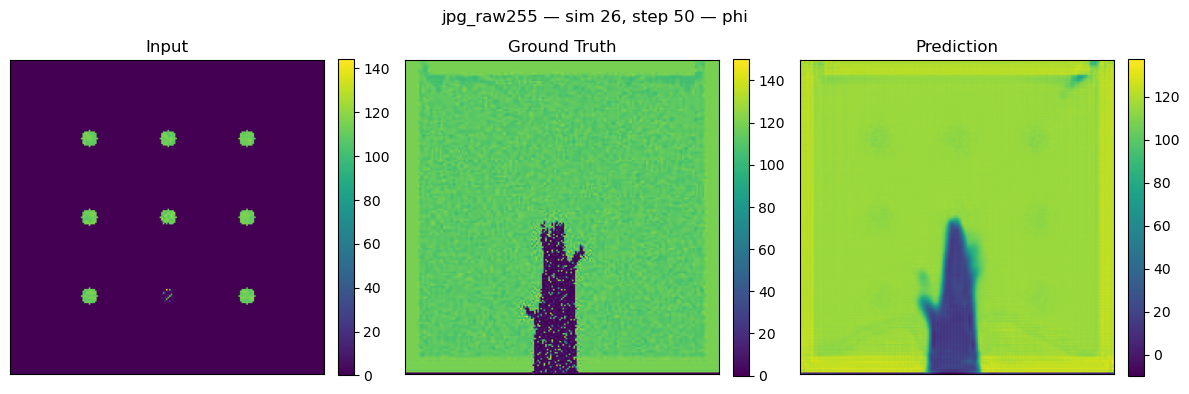

Showing predictions for mat_255


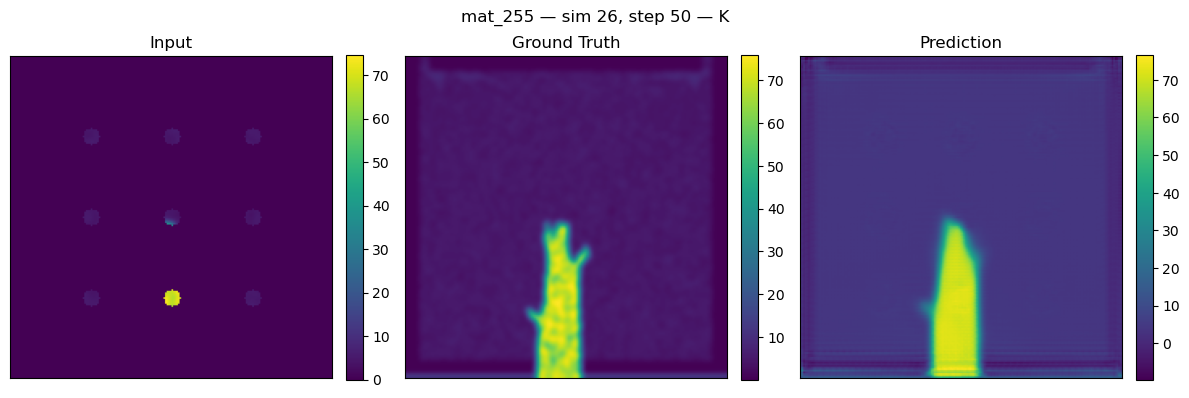

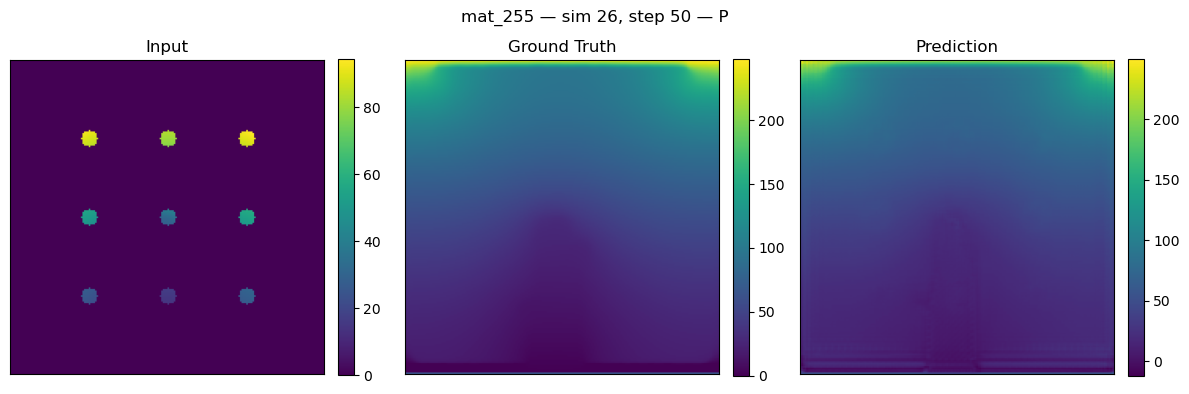

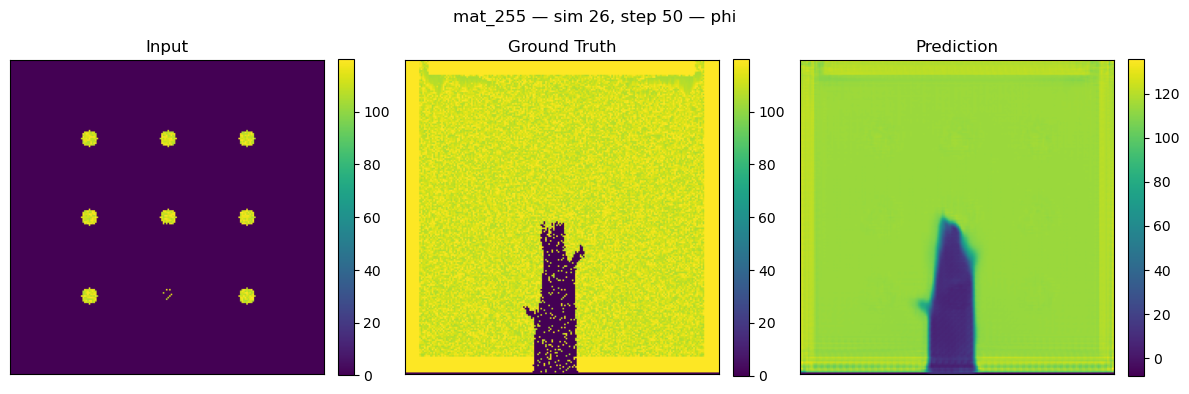

Showing predictions for mat_raw


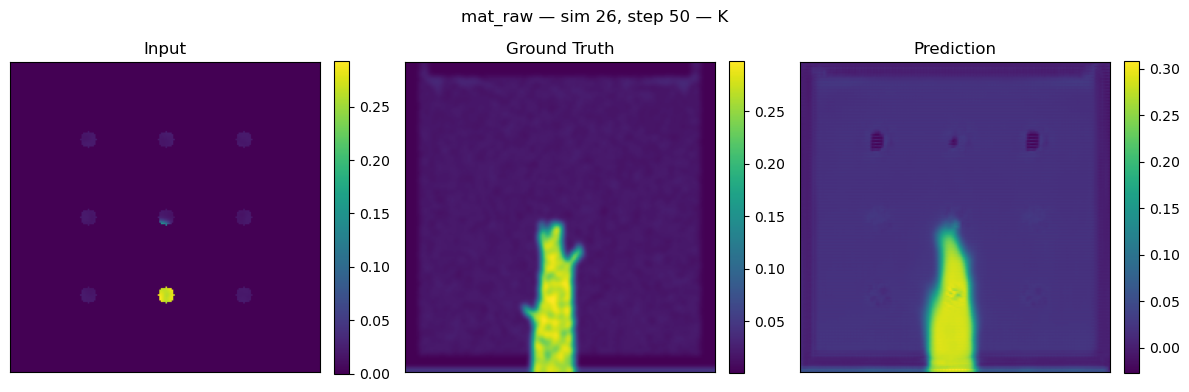

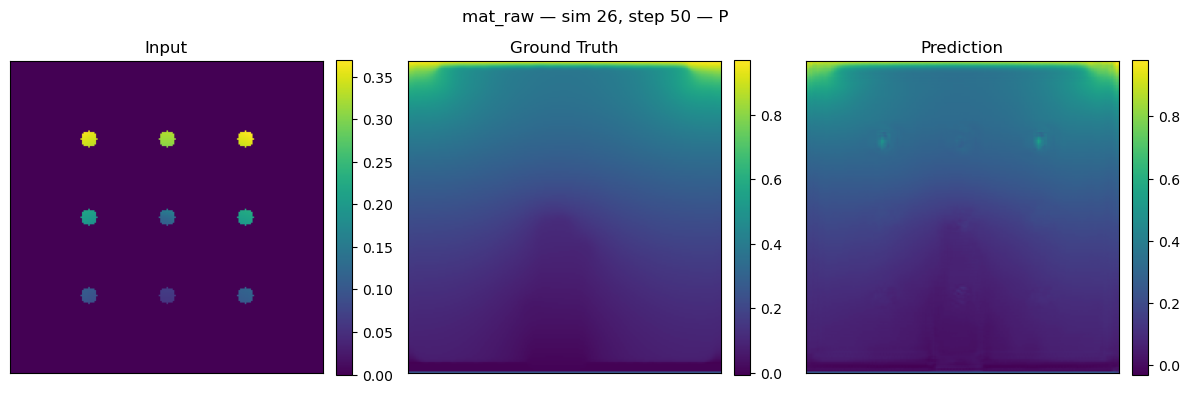

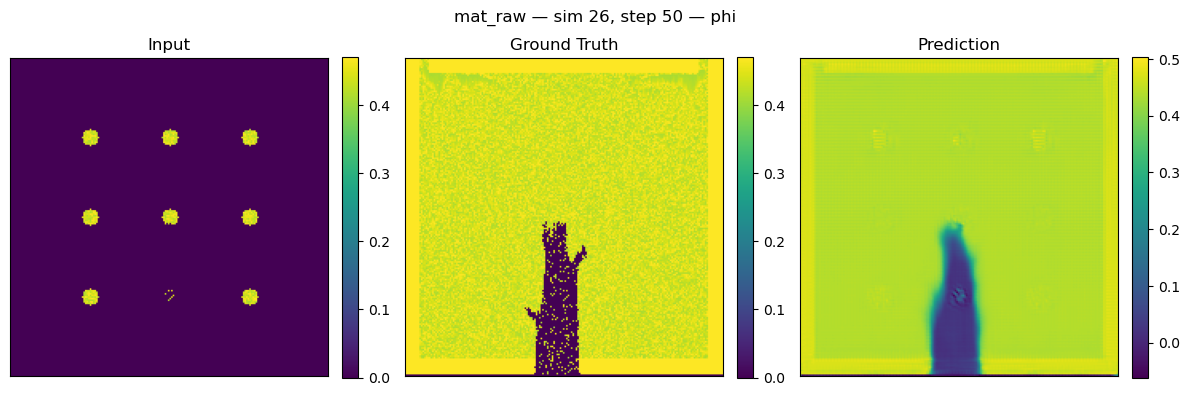

Comparing all models for channel: K


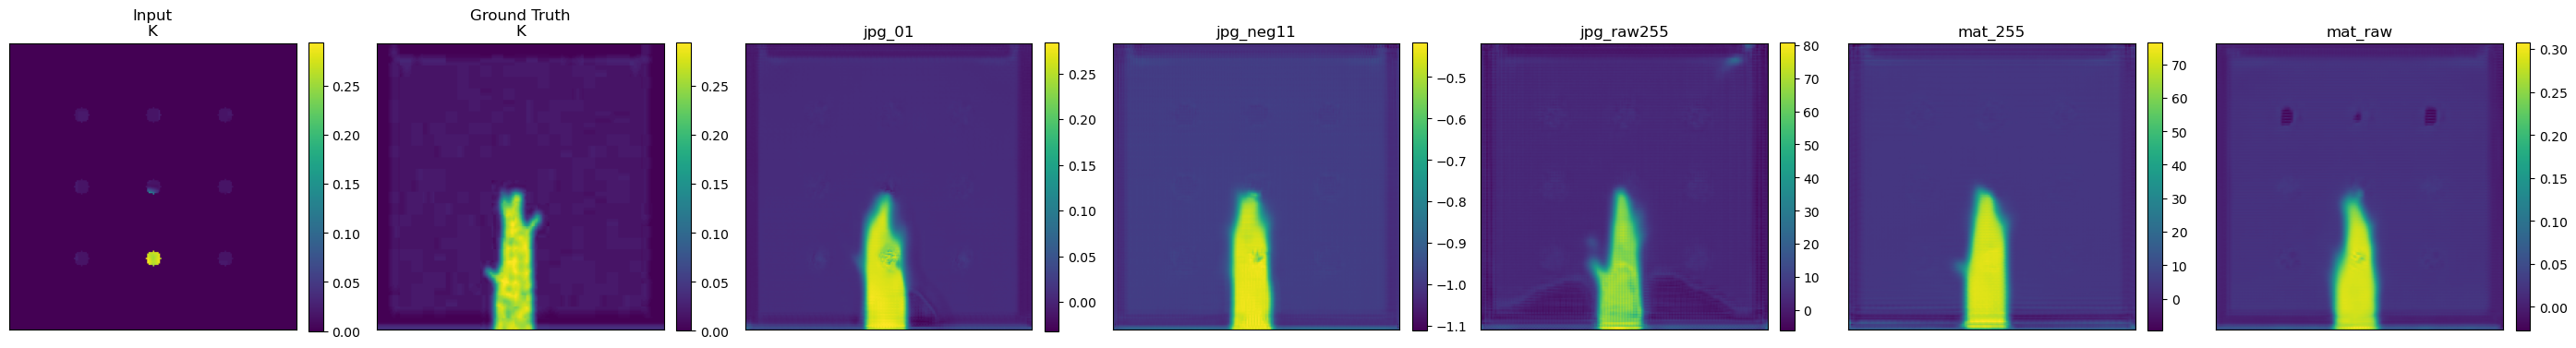

Comparing all models for channel: P


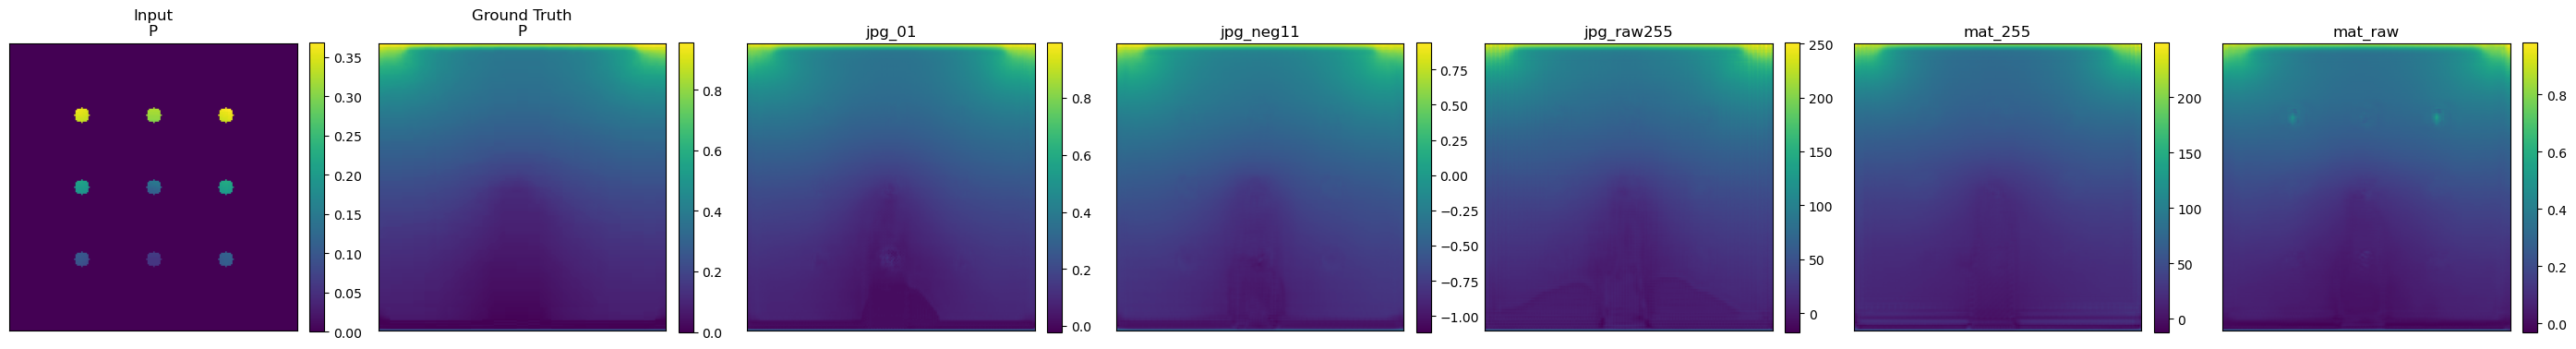

Comparing all models for channel: phi


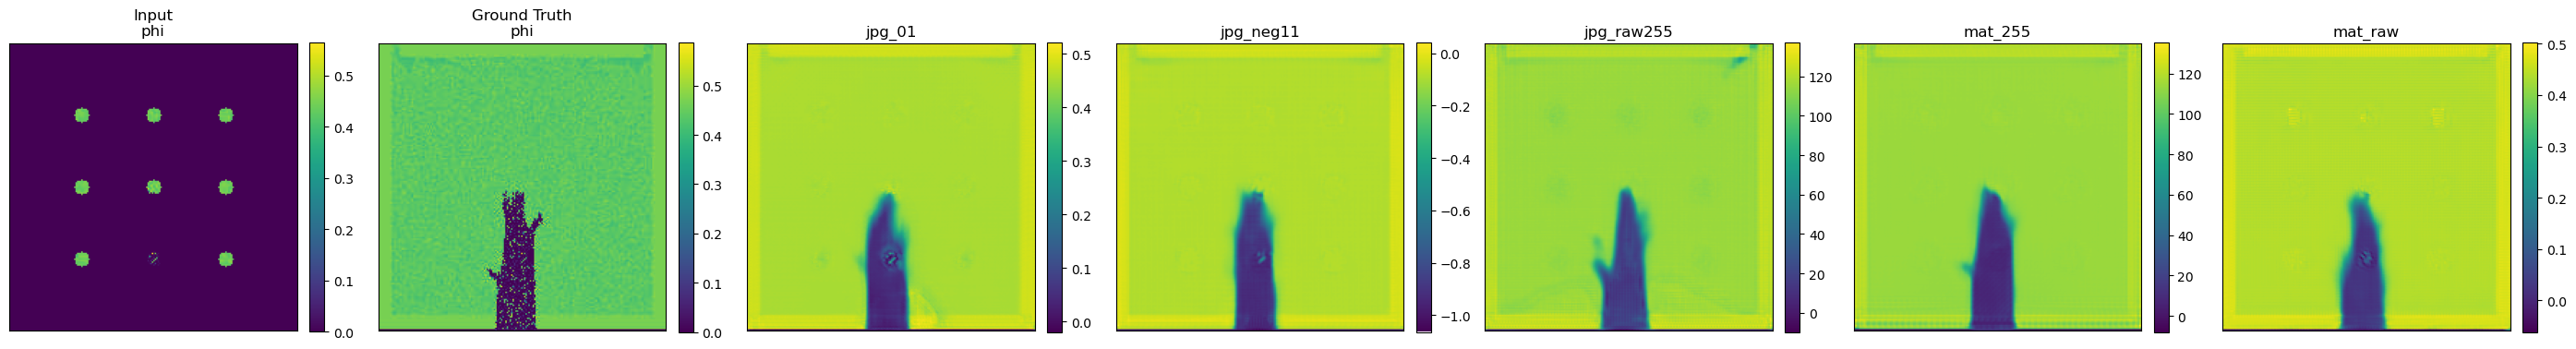

In [10]:
import os
import copy
import numpy as np
import torch
import matplotlib.pyplot as plt

import datasetsmat   # your dataset file
import unet

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -----------------------------
# USER SETTINGS
# -----------------------------
DATA_FOLDER = "./sim_test/output_folder"
RESULTS_DIR = "./experiment_results"

SIM = 26
STEP = 50

EXPERIMENTS = [
    {"name": "jpg_01",     "dataset_args": {"data_source": "jpg", "jpg_scale": "01"}},
    {"name": "jpg_neg11",  "dataset_args": {"data_source": "jpg", "jpg_scale": "neg11"}},
    {"name": "jpg_raw255", "dataset_args": {"data_source": "jpg", "jpg_scale": "raw255"}},
    {"name": "mat_255",    "dataset_args": {"data_source": "mat", "mat_variant": "255", "mat_scale": None}},
    {"name": "mat_raw",    "dataset_args": {"data_source": "mat", "mat_variant": "raw", "mat_scale": None}},
]

CHANNEL_NAMES = ["K", "P", "phi"]


# -----------------------------
# HELPERS
# -----------------------------
def load_model(model_name):
    model = unet.SmallUnet().to(device)
    model_path = os.path.join(RESULTS_DIR, f"{model_name}.pt")
    state = torch.load(model_path, map_location=device)
    model.load_state_dict(state)
    model.eval()
    return model


def load_exact_sample(sim, step, dataset_args, folder):
    """
    Directly loads the exact sim/step from files using your datasetsmat.get_all(...)
    and recreates the same masking logic as FixedDenseDatasetFull.
    """
    t_cur = torch.tensor(
        datasetsmat.get_all(
            sim,
            step,
            folder,
            data_source=dataset_args.get("data_source", "jpg"),
            jpg_scale=dataset_args.get("jpg_scale", "raw255"),
            mat_variant=dataset_args.get("mat_variant", "raw"),
            mat_scale=dataset_args.get("mat_scale", None),
        ),
        dtype=torch.float32
    )

    t_label = torch.tensor(
        datasetsmat.get_all(
            sim,
            step,
            folder,
            data_source=dataset_args.get("data_source", "jpg"),
            jpg_scale=dataset_args.get("jpg_scale", "raw255"),
            mat_variant=dataset_args.get("mat_variant", "raw"),
            mat_scale=dataset_args.get("mat_scale", None),
        ),
        dtype=torch.float32
    )

    # same masking setup as FixedDenseDatasetFull defaults
    H = dataset_args.get("H", 200)
    W = dataset_args.get("W", 200)
    points_per_side = dataset_args.get("points_per_side", 3)
    radius = dataset_args.get("radius", 5)
    channels = dataset_args.get("channels", "all")

    z = torch.zeros_like(t_cur)

    mask = torch.zeros((H, W), dtype=torch.bool)
    div = points_per_side + 1
    point_x = np.arange(W // div, W, W // div)
    point_y = np.arange(H // div, H, H // div)

    yy, xx = torch.meshgrid(torch.arange(H), torch.arange(W), indexing="ij")
    for y0 in point_y:
        for x0 in point_x:
            disk = (yy - int(y0))**2 + (xx - int(x0))**2 <= (radius**2)
            mask |= disk

    if channels == "all":
        chans = [0, 1, 2]
    elif channels == "K":
        chans = [0]
    elif channels == "P":
        chans = [1]
    elif channels == "phi":
        chans = [2]
    else:
        raise ValueError("channels must be 'all', 'K', 'P', or 'phi'")

    z[chans, :, :] = torch.where(mask, t_cur[chans, :, :], torch.zeros_like(t_cur[chans, :, :]))

    return z, t_label


def to_numpy_img(t):
    if isinstance(t, torch.Tensor):
        return t.detach().cpu().numpy()
    return np.array(t)


def show_block(title, arrs, cmap="viridis"):
    n = len(arrs)
    fig, axs = plt.subplots(1, n, figsize=(4 * n, 4))
    if n == 1:
        axs = [axs]

    for ax, (subtitle, arr) in zip(axs, arrs):
        im = ax.imshow(arr, cmap=cmap)
        ax.set_title(subtitle)
        ax.set_xticks([])
        ax.set_yticks([])
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def plot_predictions_for_experiment(exp):
    name = exp["name"]

    # defaults matching your dataset setup
    full_args = {
        "points_per_side": 3,
        "radius": 5,
        "H": 200,
        "W": 200,
        "channels": "all",
    }
    full_args.update(exp["dataset_args"])

    x, y = load_exact_sample(SIM, STEP, full_args, DATA_FOLDER)
    x_in = x.unsqueeze(0).to(device)

    model = load_model(name)
    with torch.no_grad():
        pred = model(x_in)[0]

    x = to_numpy_img(x)
    y = to_numpy_img(y)
    pred = to_numpy_img(pred)

    for c, cname in enumerate(CHANNEL_NAMES):
        show_block(
            title=f"{name} — sim {SIM}, step {STEP} — {cname}",
            arrs=[
                ("Input", x[c]),
                ("Ground Truth", y[c]),
                ("Prediction", pred[c]),
            ],
            cmap="viridis"
        )


def plot_all_models_same_channel(channel_idx=0):
    fig, axs = plt.subplots(1, len(EXPERIMENTS) + 2, figsize=(4 * (len(EXPERIMENTS) + 2), 4))

    # input/truth from first experiment's preprocessing
    first_args = {
        "points_per_side": 3,
        "radius": 5,
        "H": 200,
        "W": 200,
        "channels": "all",
    }
    first_args.update(EXPERIMENTS[0]["dataset_args"])

    x, y = load_exact_sample(SIM, STEP, first_args, DATA_FOLDER)
    x = to_numpy_img(x)
    y = to_numpy_img(y)

    im = axs[0].imshow(x[channel_idx], cmap="viridis")
    axs[0].set_title(f"Input\n{CHANNEL_NAMES[channel_idx]}")
    axs[0].set_xticks([])
    axs[0].set_yticks([])
    plt.colorbar(im, ax=axs[0], fraction=0.046, pad=0.04)

    im = axs[1].imshow(y[channel_idx], cmap="viridis")
    axs[1].set_title(f"Ground Truth\n{CHANNEL_NAMES[channel_idx]}")
    axs[1].set_xticks([])
    axs[1].set_yticks([])
    plt.colorbar(im, ax=axs[1], fraction=0.046, pad=0.04)

    for i, exp in enumerate(EXPERIMENTS):
        full_args = {
            "points_per_side": 3,
            "radius": 5,
            "H": 200,
            "W": 200,
            "channels": "all",
        }
        full_args.update(exp["dataset_args"])

        x_exp, _ = load_exact_sample(SIM, STEP, full_args, DATA_FOLDER)
        x_exp = x_exp.unsqueeze(0).to(device)

        model = load_model(exp["name"])
        with torch.no_grad():
            pred = model(x_exp)[0]

        pred = to_numpy_img(pred)

        ax = axs[i + 2]
        im = ax.imshow(pred[channel_idx], cmap="viridis")
        ax.set_title(exp["name"])
        ax.set_xticks([])
        ax.set_yticks([])
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()


# -----------------------------
# MAIN
# -----------------------------
def main():
    for exp in EXPERIMENTS:
        print(f"Showing predictions for {exp['name']}")
        plot_predictions_for_experiment(exp)

    for c, cname in enumerate(CHANNEL_NAMES):
        print(f"Comparing all models for channel: {cname}")
        plot_all_models_same_channel(channel_idx=c)


if __name__ == "__main__":
    main()